# Study 2 · The external forcings: air temperature and solar radiation

Two quantities drive the wall, and neither is measured well at the wall itself. Air temperature
is recorded inside the instrument housing, which is a sun-exposed box rather than a
meteorological screen. Solar radiation exists only in the current instrument era, and study 1
condemned 161 of its days. Everything the project will later ask of a thermal driver therefore
depends on external sources whose agreement with each other, and with the site, has to be
measured before any of them is used.

This study characterises each external source on its own terms, brings all three onto one
hourly UTC grid, and only then asks how far apart they stand.

**The sensor side is study 1's, unaltered.** Everything measured at the wall comes from
`data/interim/archive/gubbio_archive_20min.csv`. Nothing here opens an `.adc` file, re-decides a
rejection, or recomputes a correction.

1. **Load the three sources** — study 1's archive, the ground station, ERA5; onto one hourly
   UTC grid under one naming scheme.
2. **ERA5 on its own terms** — every retained variable: extent, coverage, range, the complete
   record, and the summer and winter mean daily cycles.
3. **The Gubbio station on its own terms** — the same characterisation, on the same season
   definitions, so that a difference between the two descriptions is a difference between the
   records rather than between the summaries.
4. **The common grid and the certified radiation window** — the clock each source keeps,
   measured by two independent tests, and the days on which the on-structure radiation survives
   both study 1's flags and its `sr_suspect` verdict. Measured, not assumed.
5. **Time-base harmonisation on the native grid** — a finer clock check on the archive's own
   20-minute grid: for every pair of sources, the residual reference-side displacement that
   best aligns their daily anomalies, scanned before and after correcting the ground station's
   own stamp.
6. **The two external sources against each other** — pairwise agreement between the ground
   station and ERA5, over every quantity both report, resolved by season.
7. **Air temperature, three sources compared** — level, common variation, and the structure of
   the difference by season and by time of day.
8. **Solar radiation, three sources compared** — the same, plus the calibration against the
   certified window, which is the only stretch where a local reference exists.
9. **Compatibility and substitution** — what each source is fit for, per quantity, with the
   window its evidence covers and the limitation it carries.

Steps 2 and 3 characterise every variable each source retains, not only the two forcings. A
source is described before it is used, and a description that looked only at the two channels
the study wants would not be a description of the source.

The narrative and the findings are in `report/proxy_forcing_report.pdf`. This notebook produces
the numbers and the figures that report reads.

## Imports and configuration

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

sys.path.insert(0, os.path.abspath('..'))      # studies/, for shmlib
sys.path.insert(0, os.path.abspath('../..'))   # heritageshm, at the repo root

from shmlib import (compare, figures, proxies, quality, site, solar, tables,
                   temporal_alignment, viz)

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 80)

### Parameters

| Parameter | Purpose |
|---|---|
| `ARCHIVE_CSV` | Study 1's exported archive. The only sensor-side input. Produced by `studies/01_data_exploration/`; this notebook fails if it is absent, which is the intended behaviour rather than a bug. |
| `GROUND_STATION_CSV` | The town weather station export, retrieved by `auxiliary/meteosystem_italy.py`. |
| `ERA5_CSV` | The ERA5 reanalysis export, retrieved through Oikolab by `auxiliary/oiko.py`. |
| `OUTPUT_DIR` | Where this study's tables, table bodies and figures are written. |
| `ANALYSIS_FREQ` | The grid every comparison runs on. One hour: the finest resolution at which all three sources can be compared without inventing detail in two of them. |
| `QUANTITIES` | The forcings that enter the three-source comparison. Air temperature and solar radiation; every other variable is characterised inside its own source and goes no further. |
| `SOURCES` | The sources compared, in the order they appear in every table and legend. |
| `ERA5_MAP`, `GS_MAP`, `STR_MAP` | Canonical quantity name to the column that carries it in each file. Editing a map is how the study is re-aimed at a differently-named export; nothing downstream refers to a native column name. |
| `HONOUR_SUSPECT` | Whether the days study 1 marked `sr_suspect` are excluded from the on-structure radiation. Default `True`. Setting it to `False` is a diagnostic, never a result. |
| `MIN_SAMPLES_PER_HOUR` | Twenty-minute samples an hour of the archive must carry before its mean is treated as an hourly value. An hour represented by a single slot is not an hourly mean of anything. |
| `MIN_SAMPLES_PER_HOUR_GS` | The same rule for the half-hourly station. Left at 1, which lets a half-hour whose partner is missing still report the hour it fell in; raising it to 2 requires both. |
| `SITE_TZ` | The logger's civil clock. The archive is written on it and observes daylight saving; the proxies are in UTC. The archive index is converted before anything is resampled, because an hourly mean taken on one clock and labelled with another is wrong by up to two hours for half the year. |
| `SEASON_MONTHS`, `DIURNAL_SEASONS` | The months belonging to each season, and the pair every diurnal comparison is drawn on. Summer and winter are the extremes of the Central Italian year, and the definitions match study 1 exactly so the two studies' cycles can be read against each other. |
| `MIN_DAYS_PER_HOUR` | Days an hour of a mean daily cycle must draw on before it is reported. Guards against a profile whose shape is set by two unusual days. |
| `COMPLETE_DAY` | Slots a day must carry to contribute to a mean daily cycle at all. `None` admits every day, which is the right rule for a climatology spanning eight years; study 1 uses the stricter rule because its object is the shape of one instrument's day. |
| `CENTRE_DIURNAL` | Whether each mean daily cycle is drawn as an excursion around zero, with every day centred on its own mean first, or in the channel's own units. `False` here: these panels describe what a source reports, and the level is part of that description. Centring is the right treatment where the absolute level is arbitrary, as study 1's inclination is. |
| `ERA5_SERIES_CLIP`, `GS_SERIES_CLIP`, `SERIES_CLIP_QUANTILES`, `SERIES_CLIP_PAD` | Which channels of each complete-record figure are drawn on a clipped vertical axis, and how that axis is bounded. Only the station's precipitation is clipped: it carries a single reading of 1.7 billion millimetres in an hour, and a panel scaled to it shows nothing else. The quantiles are taken over the values inside the channel's documented plausible range, so the axis excludes an impossible reading rather than trimming a heavy rainfall — a quantile large enough to hide this sample would also hide real weather. Every clipped panel carries a note, in the accent colour, saying how many samples fall outside it and how far. The clipping is a display choice and changes no value, no inventory count and no statistic. |
| `ERA5_SERIES_QUANTITIES`, `GS_SERIES_QUANTITIES` | The channels each source's complete-record figure draws, in the order it draws them. Both begin with the five `DIURNAL_QUANTITIES` in the same order, so that a reader moving between the four figures finds the channels where they were left; each source's remaining channels follow. The station's precipitation intensity is omitted: it is the depth its neighbouring panel already draws, divided by the interval, and the two panels carry the same information at different scales. Neither list narrows what is characterised — the channel inventories and the diurnal tables are computed over every retained channel. |
| `DIURNAL_QUANTITIES` | The channels each source's merged summer-and-winter figure draws, in the order it draws them, and the same list for both so that the two figures can be read against each other. The two forcings this study is about, the humidity that accompanies them, and the wind that ventilates the surface. What each source retains beyond these — dew point and precipitation in both, pressure at the station — is left to the complete-record figures and the diurnal tables, which still carry every channel: the figure selects what is worth reading hour by hour, it does not narrow the characterisation. |
| `DIURNAL_DAY_ALPHA` | Opacity of the individual days drawn in gray behind each mean. A climatology over eight years puts hundreds of days in one small panel, so the stroke has to be lighter than the one study 1 uses over a single season. |
| `CLOCK_REFERENCE`, `CLOCK_MIN_PEAK`, `CLOCK_THRESHOLD`, `CLOCK_MAX_LAG` | The clock tests. The reference is the source whose provider states UTC; the peak and threshold define a usable radiation day, matching study 1's values so the two studies cannot disagree about which day was usable; the maximum lag bounds the cross-correlation search. Twelve hours is deliberate — a longer window returns the 24-hour alias of a lead and reports it as a lag. |
| `NATIVE_FREQ` | The grid step 5's harmonisation scan runs on. The archive's own twenty minutes, finer than `ANALYSIS_FREQ`, because a residual timestamp displacement of a few minutes is invisible once everything has already been averaged into an hour. |
| `SHIFTS_MINUTES` | Candidate reference-side displacements step 5 scans, in minutes. Minus two hours to plus two hours in twenty-minute steps — wide enough to see a scan's shape flatten at its edges, which is the sign a true optimum sits inside the window rather than beyond it. |
| `HARMONISATION_PERIODS` | The two periods step 5 scans separately, because the ground station and the on-structure instrument package both changed at the February 2025 changeover: `legacy`, `site.ARCHIVE_START` to `site.LEGACY_END`, and `current`, `site.CURRENT_START` to the end of whatever is loaded (`end=None`). Study 1's `de_lib.last_archive_day` walks the raw `.adc` directory this study never opens, so the current period's end is left open rather than duplicating that walk over a path this notebook does not read. |
| `MIN_PAIRS`, `MIN_DAYS` | Support a shift's scanned correlation must have before step 5 reports it, in paired twenty-minute slots and in distinct UTC days. Matches `shmlib.temporal_alignment`'s own defaults; lowering either lets a thinly supported displacement outrank a well-supported one on noise alone. |
| `GROUND_STAMP_OFFSET` | The correction step 5 tests against the vendor stamp: `auxiliary/meteosystem_italy.py` documents a thirty-minute reporting interval but not whether a value is instantaneous or a mean, nor which edge of the interval a mean would be stamped at. Fifteen minutes is half the interval — the correction an interval mean stamped at its end requires to move it to the centre it actually describes. |
| `SHIFT_PAIRS` | The six sensor-reference pairs step 5 scans: air temperature and radiation, each between the on-structure housing and the station, the housing and ERA5, and the station and ERA5. The first name of each pair is `reference_shift_scan`'s `reference` argument, the one the scan displaces; the second, always the clock with the least doubt attached to it, is its `sensor` argument, held fixed. A positive displacement therefore always reads as "the first-named source's own stamp sits later than the second's". |
| `CROSS_SOURCE_LIMITS` | Bounds this comparison applies in place of a quantity's documented plausible range. Precipitation is capped at 20 mm in the hour, which excludes exactly one station reading — 30.1 mm, real weather, roughly twice the next largest, and the sole occupant of the upper two thirds of its panel. The hour is kept in the frame every other step uses and in the channel inventory; what this bound decides is the record the precipitation comparison describes, which is the ordinary behaviour of the two sources rather than one storm. Widen the bound to put the hour back, and the count of what each bound excluded is printed beside the table. |
| `CROSS_SOURCE_PLAUSIBLE_ONLY` | Whether the source-against-source scores are computed on values inside each quantity's documented plausible range. `True`: one impossible rainfall reading of order a billion millimetres dominates every mean square it enters, and an agreement table built from it looks like a result while being none. The reading is not deleted — it stays in the frame every other step uses, and stays counted in the channel inventory — and the number of values this step set aside is printed beside the table. Set `False` to see the unmasked scores. |
| `CROSS_SOURCE_REFERENCE`, `CROSS_SOURCE_COMPARED` | The two sides of the comparison between the external sources themselves, run over every quantity both of them report. The station is the reference, so that a positive bias reads as the reanalysis running high with respect to the local observation. Neither is a reference in the sense the on-structure record is; swapping them changes the sign of every bias and nothing else. |
| `CERTIFIED_MIN_HOURS` | Hours of surviving radiation a day must carry to count as certified. |
| `AMPLITUDE_MIN_HOURS` | Hours a day must carry to contribute to the daily amplitude and peak-hour columns. Twenty of twenty-four: a day missing its afternoon has a maximum, but not a meaningful one. |
| `STABILITY_FREQ`, `STABILITY_MIN_HOURS` | The window the bias is tracked over, and the paired hours a window must hold to be reported. Whether a source may substitute for the local measurement turns on whether its bias is *stable*, not on whether it is small. |
| `DAYLIGHT_ONLY`, `NIGHT_ELEVATION` | Whether the radiation calibration is restricted to hours the sun is above the given elevation, and that elevation. Half of every day is a substituted zero in the reference and a near-zero in the sources; a statistic over the whole day mostly measures agreement about where the sun is. |
| `COMPARISON_SPAN` | The window the three-source time-series figures are drawn over. `None` draws the full shared record, which at eight years is too dense to read; a bounded span is a display choice and changes no statistic. |
| `TICK_YEARS`, `TICK_MONTHS` | Date-tick spacing of the long multi-panel figures and of the certified-window strip. |
| `FIGSIZE_WIDTH` | Figure width in inches, fixed at the manuscript column width. |
| `QUANTITY_COLOUR`, `SOURCE_STYLE`, `MARK_COLOUR`, `SPAN_STYLE` | The colour and style scheme. Colour carries quantity identity and nothing else, held constant across every figure; where the three sources must be told apart inside one axes the distinction is line style. The six quantities the project scheme does not name are assigned in `shmlib.viz`, with each assignment's reasoning beside it. |

In [2]:
ARCHIVE_CSV = '../../data/interim/archive/gubbio_archive_20min.csv'
GROUND_STATION_CSV = '../../data/raw/proxies/meteosystem_gubbio.csv'
ERA5_CSV = '../../data/raw/proxies/oikolab_weather.csv'
OUTPUT_DIR = 'outputs'

ANALYSIS_FREQ = site.ANALYSIS_FREQ
QUANTITIES = proxies.QUANTITIES
SOURCES = proxies.SOURCES

# Canonical quantity name to the column that carries it in each file. Declared here rather
# than left to the library so that a reader of the notebook can see exactly which column of
# which file every number in this study came from.
ERA5_MAP = proxies.ERA5_MAP
GS_MAP = proxies.GS_MAP
STR_MAP = proxies.STR_MAP

HONOUR_SUSPECT = True

MIN_SAMPLES_PER_HOUR = site.MIN_SAMPLES_PER_HOUR    # archive, 20-minute native grid
MIN_SAMPLES_PER_HOUR_GS = 1                         # station, half-hourly native grid
SITE_TZ = site.SITE_TZ

# Seasons, defined exactly as study 1 defines them so the two studies' diurnal cycles can be
# read against one another.
SEASON_MONTHS = {'winter': [12, 1, 2], 'spring': [3, 4, 5],
                 'summer': [6, 7, 8], 'autumn': [9, 10, 11]}
DIURNAL_SEASONS = ('summer', 'winter')
MIN_DAYS_PER_HOUR = 5
COMPLETE_DAY = None        # every day contributes; see the parameter table
CENTRE_DIURNAL = False     # draw the level, not only the excursion
DIURNAL_DAY_ALPHA = 0.08   # opacity of the individual days behind each mean

# The channels the merged seasonal figures draw, in the order they draw them, and
# the same list for both sources so that the two figures can be read against each
# other. The full record of every retained channel is still shown by each source's
# complete-record figure, and every one of them still enters its diurnal table.
DIURNAL_QUANTITIES = ('tair', 'rh', 'sr', 'wspd', 'wdir')

# The channels each source's complete-record figure draws, in the order it draws
# them. Both open on the five channels the daily-cycle figures draw, in the same
# order, so that the four figures can be read against one another; what a source
# retains beyond those follows, and the station's precipitation intensity is left
# out as the same quantity its precipitation depth already reports.
ERA5_SERIES_QUANTITIES = ('tair', 'rh', 'sr', 'wspd', 'wdir', 'tdew', 'rain')
GS_SERIES_QUANTITIES = ('tair', 'rh', 'sr', 'wspd', 'wdir', 'tdew', 'rain',
                        'pres')

# Channels whose complete-record panel is drawn on a clipped vertical axis, and
# the quantiles bounding it. The station's precipitation carries one reading of
# 1.7 billion millimetres, which is not weather; without clipping, its panel is a
# flat line and a spike. ERA5 needs no clipping. The quantiles are taken over the
# values inside the channel's documented plausible range, so that what the axis
# excludes is the impossible reading rather than a heavy rainfall.
ERA5_SERIES_CLIP = ()
GS_SERIES_CLIP = ('rain',)
SERIES_CLIP_QUANTILES = (0.0, 1.0)
SERIES_CLIP_PAD = 0.05

# The clock tests. Both are run and both are reported; where they disagree for a channel,
# that channel is defective.
CLOCK_REFERENCE = 'era5'   # the only source whose provider states UTC
CLOCK_MIN_PEAK = 200.0     # W/m², matching study 1
CLOCK_THRESHOLD = 50.0     # W/m², matching study 1
CLOCK_MAX_LAG = 12         # hours; longer returns the 24-hour alias of a lead

# Step 5's finer harmonisation scan, run on the archive's own native grid rather
# than the hourly grid every other step shares — a residual displacement of a
# few minutes is invisible once it has already been averaged into an hour.
NATIVE_FREQ = '20min'
SHIFTS_MINUTES = list(range(-120, 121, 20))
HARMONISATION_PERIODS = [
    {'name': 'legacy', 'start': site.ARCHIVE_START, 'end': site.LEGACY_END},
    # `end=None` keeps whatever the loaded archive carries through; this study
    # never opens the raw `.adc` directory `site.last_archive_day` would need
    # to state that end explicitly.
    {'name': 'current', 'start': site.CURRENT_START, 'end': None},
]
MIN_PAIRS = 200
MIN_DAYS = 14
GROUND_STAMP_OFFSET = '15min'   # half the station's documented 30-minute interval

# The six sensor-reference pairs: (label, variable, sensor column, reference
# column). The reference column is the one `reference_shift_scan` displaces;
# the sensor column stays at its own timestamps. ERA5 plays the sensor
# wherever it appears, and the station plays it against the housing, so that
# the source with the least doubtful clock is always the one held fixed and a
# positive displacement always reads as "the pair's first-named source is
# stamped later than the second".
SHIFT_PAIRS = (
    ('str-gs', 'tair', 'tair_gs', 'tair_str'),
    ('str-era5', 'tair', 'tair_era5', 'tair_str'),
    ('gs-era5', 'tair', 'tair_era5', 'tair_gs'),
    ('str-gs', 'sr', 'sr_gs', 'sr_str'),
    ('str-era5', 'sr', 'sr_era5', 'sr_str'),
    ('gs-era5', 'sr', 'sr_era5', 'sr_gs'),
)

# The two sides of the source-against-source comparison. The station is the
# reference, so a positive bias reads as the reanalysis running high with respect
# to the local observation; neither is a reference in the sense the wall is.
CROSS_SOURCE_REFERENCE = 'gs'
CROSS_SOURCE_COMPARED = ('era5',)

# Whether the source-against-source scores are computed on plausible values only.
# The station's rainfall carries a reading of order a billion millimetres; a mean
# square over it is not a statistic. The reading stays in the data and stays
# counted in the channel inventory — what is excluded here is its effect on a
# score, and the count of what was excluded is printed beside the table.
CROSS_SOURCE_PLAUSIBLE_ONLY = True

# Bounds this comparison applies in place of the documented plausible range, per
# quantity. The station's heaviest recorded hour, 30.1 mm, is roughly twice the
# next largest and is the sole occupant of the upper two thirds of the
# precipitation panel's axis. It is real weather and is kept everywhere else in
# the study; here it is excluded so that the precipitation scores and panel
# describe the record the two sources ordinarily produce rather than one storm.
# This is the study choosing what its comparison covers, not a defect being
# removed: raise the bound to put the hour back.
CROSS_SOURCE_LIMITS = {'rain': (0.0, 20.0)}

CERTIFIED_MIN_HOURS = 1
AMPLITUDE_MIN_HOURS = 20

STABILITY_FREQ = 'MS'      # calendar months
STABILITY_MIN_HOURS = 100

DAYLIGHT_ONLY = True
NIGHT_ELEVATION = solar.NIGHT_ELEVATION

# A display choice only. Eight years of hourly data in one axes is a solid band; a bounded
# span is readable and changes no statistic in this study.
COMPARISON_SPAN = (pd.Timestamp('2025-06-01'), pd.Timestamp('2025-09-01'))
TICK_YEARS = 1
TICK_MONTHS = 2

FIGSIZE_WIDTH = viz.FIGURE_WIDTH

# The project's colour scheme and report style, defined once in `shmlib.viz`. Colour
# carries variable identity and nothing else: each quantity keeps its colour across every
# figure of this study, and where the three sources must be told apart inside one axes the
# distinction is line style.
QUANTITY_COLOUR = viz.QUANTITY_COLOUR
SOURCE_STYLE = viz.SOURCE_STYLE
MARK_COLOUR = viz.MARK_COLOUR
SPAN_STYLE = viz.SPAN_STYLE
viz.apply_report_style()

os.makedirs(OUTPUT_DIR, exist_ok=True)

## Step 1 · Load the three sources

Study 1's archive supplies the on-structure side, the two proxy files supply the external ones,
and all three are put on the hourly grid under the canonical `{quantity}_{source}` naming of
`docs/proxy-data-dictionary.md`. The unit conversions applied on load are documented there and
are not optional: ERA5 reports relative humidity as a fraction, and the ground station is
natively half-hourly.

**The clock is the load-bearing step here.** The two proxy exports carry UTC timestamps, written
as such by their retrieval scripts. The archive does not: the acquisition system writes Italian
civil time and observes daylight saving, which study 1 measured against computed solar noon and
recorded in the archive manifest. Its index is therefore converted to UTC before anything is
resampled. Two hours a year cannot be converted — the repeated hour when the civil clock falls
back is genuinely ambiguous and becomes missing, and the hour that never happens when it springs
forward is shifted out of the gap. Both are counted and reported below rather than passed over.

The three loads are joined on the **union** of their extents, not the intersection. Each source
is characterised over its own record in steps 2 and 3, and a join that kept only the shared
timestamps would silently substitute a description of the overlap for a description of the
sources.

### Parameter Tuning Guidance

`ANALYSIS_FREQ` is the grid. `MIN_SAMPLES_PER_HOUR` and `MIN_SAMPLES_PER_HOUR_GS` decide how
much of an hour must be present before its mean is reported, per source; raising either makes
every channel look sparser and none of them look different. `HONOUR_SUSPECT` decides whether
study 1's condemned radiation days reach this study at all, and belongs at `True`. `SITE_TZ` is
the logger's clock and is a measured fact, not a choice — changing it invalidates every
comparison in the notebook.

In [3]:
era5 = proxies.load_era5(ERA5_CSV, column_map=ERA5_MAP, freq=ANALYSIS_FREQ)
ground = proxies.load_ground_station(GROUND_STATION_CSV, column_map=GS_MAP,
                                     freq=ANALYSIS_FREQ,
                                     min_count=MIN_SAMPLES_PER_HOUR_GS)
sensor, sensor_provenance = proxies.load_sensor_forcings(
    ARCHIVE_CSV, column_map=STR_MAP, freq=ANALYSIS_FREQ, tz=SITE_TZ,
    honour_suspect=HONOUR_SUSPECT, min_count=MIN_SAMPLES_PER_HOUR)

for name, frame in (('ERA5', era5), ('ground station', ground),
                    ('on-structure', sensor)):
    print(f'{name:15s} {len(frame.columns)} channels, '
          f'{frame.index.min()} to {frame.index.max()}')
    if frame.attrs.get('columns_absent'):
        print(f'{"":15s} columns absent from the file: '
              f'{frame.attrs["columns_absent"]}')

print()
for key, value in sensor_provenance.items():
    print(f'  {key:32s} {value}')

ERA5            7 channels, 2018-01-01 00:00:00 to 2026-08-12 00:00:00
ground station  9 channels, 2018-10-17 09:00:00 to 2026-08-12 22:00:00
on-structure    2 channels, 2018-07-25 22:00:00 to 2026-08-20 22:00:00

  native_extent                    (Timestamp('2018-07-26 00:00:00'), Timestamp('2026-08-21 00:00:00'))
  native_rows                      212257
  native_step                      20min
  clock                            Europe/Rome
  ambiguous_timestamps_dropped     24
  suspect_days                     161
  suspect_samples_removed          11416
  night_corrected_samples          11339
  honour_suspect                   True


In [4]:
df = proxies.harmonise([sensor, ground, era5], freq=ANALYSIS_FREQ)
print(f'Harmonised: {len(df):,} hourly slots, {len(df.columns)} channels, '
      f'{df.index.min()} to {df.index.max()}')

sources = {'str': sensor, 'gs': ground, 'era5': era5}
inventory = proxies.source_inventory(sources)
display(inventory)
inventory.to_csv(f'{OUTPUT_DIR}/PF_01_source_inventory.csv', index=False)

Harmonised: 75,695 hourly slots, 18 channels, 2018-01-01 00:00:00 to 2026-08-20 22:00:00


,source,label,nature,measures,native_step_documented,native_step_measured,first,last,days,native_rows,duplicates_dropped,n_channels
0,str,On-structure,Instrument housing on the monitored wall,Air inside the instrument housing on the monit...,20min,20min,2018-07-26 00:00:00,2026-08-21 00:00:00,2949,212257,0,2
1,gs,Ground station,Ground-based meteorological station in Gubbio ...,Standard-exposure weather station in Gubbio town,30min,0 days 00:30:00,2018-10-17 09:00:00,2026-08-12 22:00:00,2857,133072,124,9
2,era5,ERA5,Gridded atmospheric reanalysis,Reanalysis average over a grid cell of roughly...,1h,0 days 01:00:00,2018-01-01 00:00:00,2026-08-12 00:00:00,3146,75090,0,7


In [5]:
# The documented native interval sits beside the measured one, so the report can say whether
# the file behaves as its retrieval script claims rather than assuming it does.
tables.write_table(
    inventory, f'{OUTPUT_DIR}/PF_T01_source_inventory.tex',
    columns=[
        ('label', None),
        ('nature', None),
        ('native_step_documented', tables.texttt),
        ('native_step_measured', tables.texttt),
        (tables.date_cell('first'), None),
        (tables.date_cell('last'), None),
        ('days', ','),
        ('native_rows', ','),
        ('duplicates_dropped', ','),
    ])

'outputs/PF_T01_source_inventory.tex'

## Step 2 · ERA5 on its own terms

ERA5 combines numerical weather prediction with assimilated observations into a spatially
continuous reconstruction, and the series used here was extracted at the monitoring coordinates.
It represents a grid cell of roughly nine kilometres, which is not expected to reproduce the
microclimate of a sun-exposed instrument enclosure. Its possible value is continuity, and
continuity is only worth having if the record is actually continuous — so the first thing asked
of it is what it contains.

Every retained variable is characterised, not only the two forcings. The complete record is
drawn as one aligned multi-panel chart with gaps preserved, and the mean daily cycles follow in
a single figure: a channel to a row, a season to a column, each panel drawing every contributing
day in gray behind its mean and naming, in its title, how many days that mean rests on and the
peak-to-trough amplitude it traces. The two seasons of a row share one vertical scale, which is
the reason for putting them in one figure — how a channel's day differs between summer and
winter is then a difference in the drawn shape rather than something a reader must reconstruct
from two axes with different limits on two separate pages.

The figure draws five of the seven retained channels, named in `DIURNAL_QUANTITIES`: the
two forcings this study is about, the humidity that accompanies them, and the wind that
ventilates the surface. Dew point and precipitation keep their place in the complete-record
figure and in the diurnal table, which are computed over every retained channel; what narrows
here is the figure, not the characterisation.

Wind direction is circular data and is treated as such throughout: averaged by the unit-vector
method, drawn as markers on a compass axis, and never connected by a line, because a line
joining 350 degrees to 10 degrees sweeps backwards across the whole axis and is a lie about the
data.

### Parameter Tuning Guidance

`ERA5_MAP` selects which of the Oikolab response's variables are retained; the response also
carries skin temperature, downward thermal radiation and snowfall, which this study does not use
and therefore does not load. `SEASON_MONTHS` and `DIURNAL_SEASONS` fix the season pair and match
study 1 exactly. `MIN_DAYS_PER_HOUR` suppresses an hour of a mean cycle that rests on too few
days; `COMPLETE_DAY` decides whether a partly observed day may contribute at all, and is `None`
here because the object is a climatology rather than the shape of one instrument's day.

In [6]:
era5_channels = proxies.channel_inventory(df, 'era5', column_map=ERA5_MAP)
display(era5_channels)
era5_channels.to_csv(f'{OUTPUT_DIR}/PF_02_era5_channels.csv', index=False)

tables.write_table(
    era5_channels, f'{OUTPUT_DIR}/PF_T02_era5_channels.tex',
    columns=[
        ('name', None),
        ('native_column', tables.texttt),
        ('unit', tables.texttt),
        ('conversion', tables.texttt),
        (tables.date_cell('first'), None),
        (tables.date_cell('last'), None),
        ('n_valid', ','),
        ('coverage_pct', '.1f'),
        ('min', '.1f'),
        ('median', '.1f'),
        ('max', '.1f'),
        ('n_implausible', ','),
    ])

,channel,quantity,name,native_column,unit,unit_confirmed,conversion,first,last,n_valid,n_slots,coverage_pct,min,median,max,n_implausible
0,tair_era5,tair,Air temperature,temperature (degC),degC,True,,2018-01-01,2026-08-12,75090,75481,99.481989,-12.55,12.960,37.02,0
1,rh_era5,rh,Relative humidity,relative_humidity (0-1),%,True,x 100,2018-01-01,2026-08-12,75090,75481,99.481989,18.00,77.000,100.00,0
2,tdew_era5,tdew,Dew-point temperature,dewpoint_temperature (degC),degC,True,,2018-01-01,2026-08-12,75090,75481,99.481989,-14.63,8.720,23.72,0
3,sr_era5,sr,Solar radiation,surface_solar_radiation (W/m^2),W/m2,True,,2018-01-01,2026-08-12,75090,75481,99.481989,0.00,8.660,945.36,0
4,rain_era5,rain,Precipitation,total_precipitation (mm of water equivalent),mm,True,,2018-01-01,2026-08-12,75090,75481,99.481989,0.00,0.000,9.43,0
5,wspd_era5,wspd,Wind speed,wind_speed (m/s),m/s,True,,2018-01-01,2026-08-12,75090,75481,99.481989,0.00,1.940,10.54,0
6,wdir_era5,wdir,Wind direction,wind_direction (deg),deg,True,,2018-01-01,2026-08-12,75090,75481,99.481989,NaN,182.135,NaN,0


'outputs/PF_T02_era5_channels.tex'

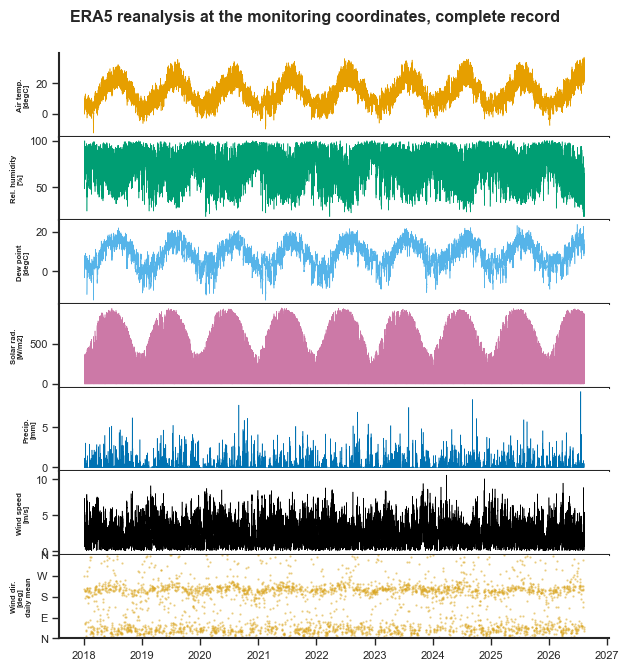

In [7]:
era5_columns = [f'{quantity}_era5' for quantity in ERA5_MAP
                if f'{quantity}_era5' in df.columns]
era5_series_columns = [f'{quantity}_era5' for quantity in ERA5_SERIES_QUANTITIES
                       if f'{quantity}_era5' in df.columns]

fig = figures.plot_source_panels(
    df, era5_series_columns,
    title='ERA5 reanalysis at the monitoring coordinates, complete record',
    tick_years=TICK_YEARS, clip=ERA5_SERIES_CLIP,
    clip_quantiles=SERIES_CLIP_QUANTILES, clip_pad=SERIES_CLIP_PAD,
    save_path=OUTPUT_DIR, filename='PF_F01_era5_series')

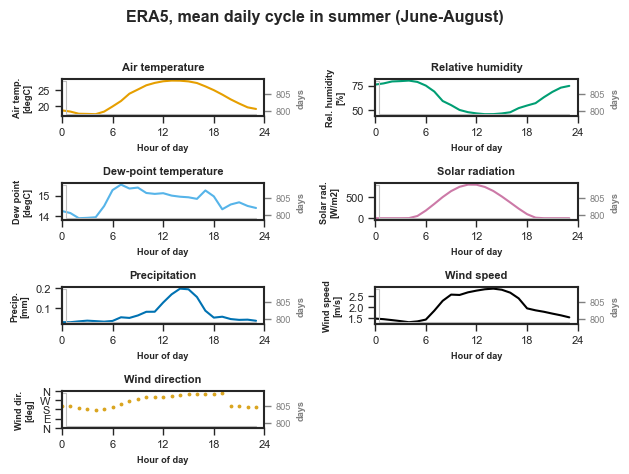

In [8]:
era5_diurnal_columns = [f'{quantity}_era5' for quantity in DIURNAL_QUANTITIES
                        if f'{quantity}_era5' in df.columns]

fig = figures.plot_diurnal_season_grid(
    df, era5_diurnal_columns, DIURNAL_SEASONS, SEASON_MONTHS,
    title='ERA5, mean daily cycle by season (June-August, December-February)',
    min_days=MIN_DAYS_PER_HOUR, complete_day=COMPLETE_DAY,
    centre=CENTRE_DIURNAL, background_alpha=DIURNAL_DAY_ALPHA,
    save_path=OUTPUT_DIR, filename='PF_F02_era5_diurnal_seasons')

In [10]:
era5_diurnal = compare.diurnal_table(df, era5_columns, DIURNAL_SEASONS,
                                     SEASON_MONTHS, min_days=MIN_DAYS_PER_HOUR,
                                     complete_day=COMPLETE_DAY)
era5_diurnal.to_csv(f'{OUTPUT_DIR}/PF_03_era5_diurnal.csv', index=False)
print(f'{len(era5_diurnal):,} rows: {era5_diurnal["channel"].nunique()} channels '
      f'x {era5_diurnal["season"].nunique()} seasons x 24 hours')

336 rows: 7 channels x 2 seasons x 24 hours


## Step 3 · The Gubbio station on its own terms

The Meteosystem source is a ground-based station in Gubbio. In contrast to the spatial average
ERA5 represents, it records conditions at one location. That location is closer to the monitored
structure than a regional grid is, but distance alone does not establish representativeness:
elevation, surrounding surfaces, shading, sensor height and screen exposure may all separate the
station record from the microclimate at the wall.

The characterisation is the same one step 2 applied, on the same season definitions, the same
display conventions and the same five channels in the same order, so that a difference between
the two descriptions is a difference between the records rather than between the summaries. The
mean daily cycles are again one figure with a channel to a row and a season to a column, the two
panels of a row sharing one vertical scale; the station's remaining channels keep their place in
the complete-record figure and in the diurnal table below, both of which cover all nine.

The station is natively half-hourly, so each hour of the grid is the mean of the two
observations inside it, and each direction the unit-vector mean of the same two. Its wind
direction is recorded as compass sectors and was converted to degrees on the meteorological
convention — the direction the wind blows *from*, clockwise from north — by the retrieval
script, which until this study discarded the field entirely.

### Parameter Tuning Guidance

`GS_MAP` selects the retained fields. The station also reports the interval minimum and maximum
of the temperature and the speed and direction of the gust; those describe the sampling within
an interval rather than a distinct quantity and are not characterised here.
`MIN_SAMPLES_PER_HOUR_GS` decides whether an hour that kept only one of its two half-hours may
still report; it is 1, which lets it. Everything else is as in step 2 and must stay so — the
comparability of the two characterisations is the point.

In [11]:
gs_channels = proxies.channel_inventory(df, 'gs', column_map=GS_MAP)
display(gs_channels)
gs_channels.to_csv(f'{OUTPUT_DIR}/PF_04_gs_channels.csv', index=False)

# The unit of the precipitation intensity is this study's inference rather than the station's
# statement, and the table says which rows carry a confirmed unit so the report need not.
unconfirmed = gs_channels.loc[~gs_channels['unit_confirmed'], 'name'].tolist()
if unconfirmed:
    print(f'Unit not confirmed from source documentation: {unconfirmed}')

tables.write_table(
    gs_channels, f'{OUTPUT_DIR}/PF_T04_gs_channels.tex',
    columns=[
        ('name', None),
        ('native_column', tables.texttt),
        ('unit', tables.texttt),
        ('unit_confirmed', tables.yes_no),
        (tables.date_cell('first'), None),
        (tables.date_cell('last'), None),
        ('n_valid', ','),
        ('coverage_pct', '.1f'),
        ('min', '.1f'),
        ('median', '.1f'),
        ('max', '.1f'),
        ('n_implausible', ','),
    ])

,channel,quantity,name,native_column,unit,unit_confirmed,conversion,first,last,n_valid,n_slots,coverage_pct,min,median,max,n_implausible
0,tair_gs,tair,Air temperature,Temp,degC,True,,2018-10-17 09:00:00,2026-08-12 22:00:00,66905,68558,97.588903,-5.45,13.55,3.820000e+01,0
1,rh_gs,rh,Relative humidity,Umid,%,True,,2018-10-17 09:00:00,2026-08-12 22:00:00,64953,68558,94.741679,1.00,70.50,9.750000e+01,0
2,tdew_gs,tdew,Dew-point temperature,Dew pt,degC,True,,2018-10-17 09:00:00,2026-08-12 22:00:00,66914,68558,97.602030,-19.90,7.85,2.390000e+01,0
3,wspd_gs,wspd,Wind speed,Vento,m/s,True,,2018-10-17 09:00:00,2026-08-12 22:00:00,66631,68558,97.189241,0.00,3.20,2.735000e+01,0
4,wdir_gs,wdir,Wind direction,Dir,deg,True,,2018-10-17 09:00:00,2026-08-12 22:00:00,66975,68558,97.691006,NaN,168.75,NaN,0
5,pres_gs,pres,Atmospheric pressure,Press,hPa,True,,2018-10-17 09:00:00,2026-08-12 22:00:00,66117,68558,96.439511,939.65,968.05,9.929000e+02,0
6,rain_gs,rain,Precipitation,Pioggia,mm,True,,2018-10-17 09:00:00,2026-08-12 22:00:00,66976,68558,97.692465,0.00,0.00,1.703392e+09,1
7,rain_rate_gs,rain_rate,Precipitation intensity,Int.Pio.,mm/h,False,,2018-10-17 09:00:00,2026-08-12 22:00:00,66975,68558,97.691006,0.00,0.00,1.702139e+09,5
8,sr_gs,sr,Solar radiation,Rad.Sol.,W/m2,True,,2018-10-17 09:00:00,2026-08-12 22:00:00,66965,68558,97.676420,0.00,4.00,1.072500e+03,0


Unit not confirmed from source documentation: ['Precipitation intensity']


'outputs/PF_T04_gs_channels.tex'

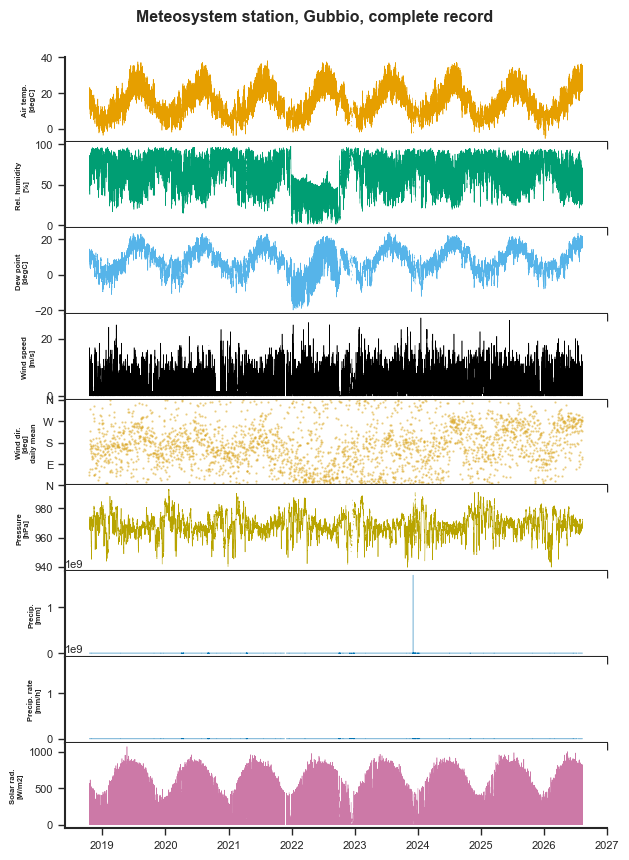

In [12]:
gs_columns = [f'{quantity}_gs' for quantity in GS_MAP
              if f'{quantity}_gs' in df.columns]
gs_series_columns = [f'{quantity}_gs' for quantity in GS_SERIES_QUANTITIES
                     if f'{quantity}_gs' in df.columns]

fig = figures.plot_source_panels(
    df, gs_series_columns,
    title='Meteosystem station, Gubbio, complete record',
    tick_years=TICK_YEARS, clip=GS_SERIES_CLIP,
    clip_quantiles=SERIES_CLIP_QUANTILES, clip_pad=SERIES_CLIP_PAD,
    save_path=OUTPUT_DIR, filename='PF_F04_gs_series')

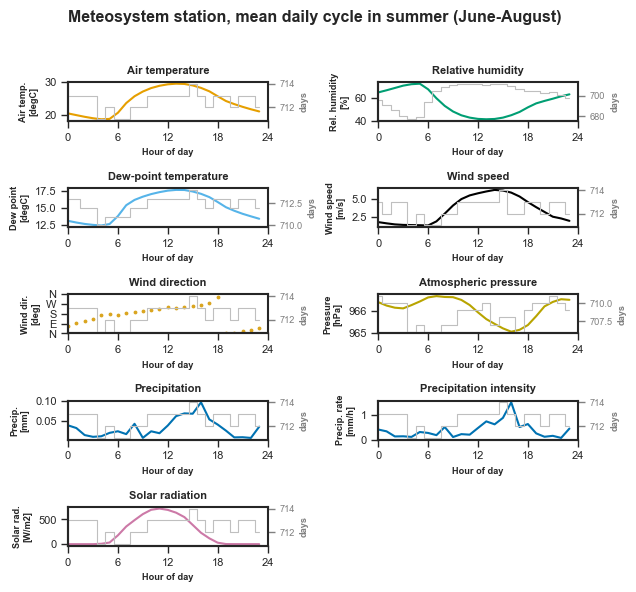

In [13]:
gs_diurnal_columns = [f'{quantity}_gs' for quantity in DIURNAL_QUANTITIES
                      if f'{quantity}_gs' in df.columns]

fig = figures.plot_diurnal_season_grid(
    df, gs_diurnal_columns, DIURNAL_SEASONS, SEASON_MONTHS,
    title='Meteosystem station, mean daily cycle by season '
          '(June-August, December-February)',
    min_days=MIN_DAYS_PER_HOUR, complete_day=COMPLETE_DAY,
    centre=CENTRE_DIURNAL, background_alpha=DIURNAL_DAY_ALPHA,
    save_path=OUTPUT_DIR, filename='PF_F05_gs_diurnal_seasons')

In [15]:
gs_diurnal = compare.diurnal_table(df, gs_columns, DIURNAL_SEASONS, SEASON_MONTHS,
                                   min_days=MIN_DAYS_PER_HOUR,
                                   complete_day=COMPLETE_DAY)
gs_diurnal.to_csv(f'{OUTPUT_DIR}/PF_05_gs_diurnal.csv', index=False)
print(f'{len(gs_diurnal):,} rows: {gs_diurnal["channel"].nunique()} channels '
      f'x {gs_diurnal["season"].nunique()} seasons x 24 hours')

432 rows: 9 channels x 2 seasons x 24 hours


## Step 4 · The common grid and the certified radiation window

The two forcings are now on one hourly UTC grid with the on-structure record beside them. Two
things have to be established before any of them are compared.

**The clock.** A source that keeps a different clock cannot be compared on a shared index at
all, and the offset between two clocks is not something a correlation will reveal — a series
shifted by an hour still correlates well with itself. Two independent tests are run: an absolute
one, locating each day's radiation midpoint against solar noon computed from the site longitude,
and a relative one, cross-correlating against the source whose provider states UTC. Where the
two disagree for a channel, that channel is defective. Study 1 already recorded the case to
expect: the on-structure radiation reads roughly sixty watts at midnight and places its own
solar noon after its temperature maximum, which is why it is not usable as a clock reference.

**The certified window.** The on-structure radiation channel exists only from the February 2025
changeover, carries rejections of its own, and was condemned by study 1 on 161 days for having
no diurnal cycle at all. What survives both is short, but it is the only measurement in the
project that sees the sky this wall sees. Its extent is computed here, because every calibration
in step 8 is conditioned on it — and it is reported as runs and gaps rather than as a single
span, since a window advertised as five months that is in fact a dozen fragments supports a
different claim from one that is not.

One property of the corrected column matters to any statistic taken over the dark hours: where
the flag reads `night`, the `_ok` value is a substituted zero rather than a measurement. It is
the only number in any `_ok` column that was not measured, and it is counted here rather than
quietly averaged in.

### Parameter Tuning Guidance

`CLOCK_REFERENCE` is the source the relative test measures against and should stay `era5`, the
only source whose timestamps its provider states as UTC. `CLOCK_MIN_PEAK` and `CLOCK_THRESHOLD`
define a usable radiation day and match study 1's values, so the two studies cannot disagree
about which day was usable. `CLOCK_MAX_LAG` bounds the cross-correlation search at twelve hours;
a wider window returns the 24-hour alias of a lead and reports it as a lag.
`CERTIFIED_MIN_HOURS` decides how much surviving radiation a day needs to count as certified.
`HONOUR_SUSPECT` decides whether the 161 condemned days are excluded at all — leave it `True`,
since setting it `False` shows what the channel reported on those days, which is a diagnostic
and never a result.

In [16]:
str_channels = proxies.channel_inventory(df, 'str', column_map=STR_MAP)
display(str_channels)
str_channels.to_csv(f'{OUTPUT_DIR}/PF_06_str_channels.csv', index=False)

tables.write_table(
    str_channels, f'{OUTPUT_DIR}/PF_T06_str_channels.tex',
    columns=[
        ('name', None),
        ('native_column', tables.texttt),
        ('unit', tables.texttt),
        (tables.date_cell('first'), None),
        (tables.date_cell('last'), None),
        ('n_valid', ','),
        ('coverage_pct', '.1f'),
        ('min', '.1f'),
        ('median', '.1f'),
        ('max', '.1f'),
        ('n_implausible', ','),
    ])

,channel,quantity,name,native_column,unit,unit_confirmed,conversion,first,last,n_valid,n_slots,coverage_pct,min,median,max,n_implausible
0,tair_str,tair,Air temperature,tair,degC,True,,2018-07-25 22:00:00,2026-08-19 17:00:00,49643,70724,70.192580,-5.171667,12.023333,38.930000,0
1,sr_str,sr,Solar radiation,n_sr_ok,W/m2,True,,2025-02-20 21:00:00,2026-08-19 17:00:00,5256,70724,7.431706,0.000000,40.251667,1353.666667,0


'outputs/PF_T06_str_channels.tex'

In [17]:
clock = quality.clock_check(df, 'sr', sources=SOURCES, reference=CLOCK_REFERENCE,
                            min_daily_peak=CLOCK_MIN_PEAK,
                            threshold=CLOCK_THRESHOLD, max_lag_hours=CLOCK_MAX_LAG)
display(clock)
clock.to_csv(f'{OUTPUT_DIR}/PF_07_clock_check.csv', index=False)

disagreeing = clock.loc[clock['tests_agree'] == False, 'channel'].tolist()
if disagreeing:
    print(f'Clock tests disagree for: {disagreeing}. '
          f'A channel whose two clock tests disagree is defective, not merely offset.')

tables.write_table(
    clock, f'{OUTPUT_DIR}/PF_T07_clock_check.tex',
    columns=[
        ('channel', tables.texttt),
        ('n_days_solar', ','),
        ('solar_offset_h', '.2f'),
        ('solar_offset_iqr_h', '.2f'),
        ('xcorr_lag_h', '.0f'),
        ('xcorr_r', '.3f'),
        ('tests_agree', tables.yes_no),
    ])

,source,channel,n_days_solar,solar_offset_h,solar_offset_iqr_h,xcorr_lag_h,xcorr_r,tests_agree
0,str,sr_str,215,-0.223681,0.718155,1.0,0.932113,False
1,gs,sr_gs,2469,0.109860,0.540437,0.0,0.930025,True
2,era5,sr_era5,2965,0.435074,0.345693,0.0,1.000000,True


Clock tests disagree for: ['sr_str']. A channel whose two clock tests disagree is defective, not merely offset.


'outputs/PF_T07_clock_check.tex'

In [18]:
certified_days, certified = quality.certified_sr_window(
    sensor, column='sr_str', min_hours=CERTIFIED_MIN_HOURS)

for key, value in certified.items():
    print(f'  {key:20s} {value}')

certified_frame = pd.DataFrame([certified])
certified_frame.to_csv(f'{OUTPUT_DIR}/PF_08_certified_sr_window.csv',
                       index=False)

tables.write_table(
    certified_frame, f'{OUTPUT_DIR}/PF_T08_certified_sr_window.tex',
    columns=[
        (tables.date_cell('first'), None),
        (tables.date_cell('last'), None),
        ('n_days', ','),
        ('span_days', ','),
        ('coverage_pct', '.1f'),
        ('n_runs', ','),
        ('longest_run_days', ','),
        ('longest_gap_days', ','),
        ('n_hours', ','),
    ])

  first                2025-02-20 00:00:00
  last                 2026-08-19 00:00:00
  n_days               224
  span_days            546
  coverage_pct         41.02564102564103
  n_runs               4
  longest_run_days     157
  n_gaps               3
  longest_gap_days     275
  n_hours              5256


'outputs/PF_T08_certified_sr_window.tex'

state
certified    224
no record    164
condemned    159
Name: count, dtype: int64

Certified days: 224, agreed by the census and the window summary.


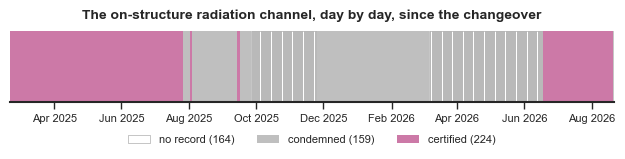

In [19]:
# The census needs the radiation channel *before* the suspect verdict is applied, so the days
# study 1 condemned can be counted rather than merely absent — the frame loaded above no longer
# carries them. It is read on the same grid, by the same rule, so that the certified day count
# below and the one in the window summary above are the same number rather than two.
sr_record = quality.load_sr_record(ARCHIVE_CSV, freq=ANALYSIS_FREQ, tz=SITE_TZ,
                                   min_count=MIN_SAMPLES_PER_HOUR)
census = quality.sr_day_census(sr_record['sr'], sr_record['suspect'],
                               sr_record['flag'])
display(census['state'].value_counts())
census.to_csv(f'{OUTPUT_DIR}/PF_09_sr_day_census.csv', index=False)

# The two statements about the certified window must agree, and this is where a future change
# to either would be caught.
n_certified = int((census['state'] == 'certified').sum())
if n_certified != certified['n_days']:
    print(f'MISMATCH: census says {n_certified} certified days, '
          f'the window summary says {certified["n_days"]}')
else:
    print(f'Certified days: {n_certified}, agreed by the census and the window summary.')

fig = figures.plot_certified_window(
    census,
    title='The on-structure radiation channel, day by day, since the changeover',
    tick_months=TICK_MONTHS, save_path=OUTPUT_DIR,
    filename='PF_F07_certified_sr_window')

## Step 5 · Time-base harmonisation on the native grid

The clock check above runs on the hourly grid, and an hourly mean absorbs a residual timestamp
error of a few minutes without a trace: two series stamped fifteen minutes apart still average
into the same hour. This step repeats the same kind of question — is a channel's clock where it
claims to be? — on the archive's own twenty-minute grid, fine enough to see a displacement that
small, and asks it of every pair the three sources can form rather than of one channel against
a fixed reference.

For each of the six pairs — air temperature and radiation, each between the on-structure housing
and the station, the housing and ERA5, and the station and ERA5 — the second-named source, always
the one with the least doubt attached to its clock, is held at its own timestamps, and the first
is displaced by every candidate in `SHIFTS_MINUTES`, positive meaning its own stamp sits later
than the true observation time. The correlation of the two series' daily anomalies is scanned
across the candidates, separately for the legacy and the current instrument era, because the
on-structure package changed at the February 2025 changeover and its housing did not.

The scan is run twice more than that: once against the ground station's export exactly as its
vendor stamps it, and once after moving that stamp back by `GROUND_STAMP_OFFSET`, the correction
a thirty-minute interval mean stamped at its end would need to sit at the centre it actually
describes. `auxiliary/meteosystem_italy.py` documents the interval but not which of those two
the export is, so both are scanned and the data are left to say which reading brings the station
closer to a clock it shares with nothing else.

Two results are already known before the scan is drawn, from the same-logger split this study's
clock check performs at the hourly grid: air temperature is recorded by both the on-structure
housing and the ground station, so a pair that involves neither the housing nor the station's
stamping error — `str`-`era5` — isolates the housing's own physical lead over free air from any
clock question, because the reanalysis carries no reporting-interval ambiguity of its own. A pair
that changes noticeably once `GROUND_STAMP_OFFSET` is applied is a pair whose disagreement was, at
least in part, the station's stamp; a pair that does not move is telling a story the correction
cannot touch.

### Parameter Tuning Guidance

`NATIVE_FREQ` is the grid this step scans on, finer than `ANALYSIS_FREQ` for the reason above.
`SHIFTS_MINUTES` bounds the candidates scanned; a curve still climbing at either edge is a sign
the window was drawn too narrow, the same warning `shmlib.figures.plot_lag_curves` carries for a
coupling scan. `HARMONISATION_PERIODS` splits the scan at the instrument changeover, since the
two packages are different hardware; the current period's end is left open (`end=None`) rather
than read from the raw archive, which this study never opens. `MIN_PAIRS` and `MIN_DAYS` are the
same support thresholds `shmlib.temporal_alignment` defaults to, named here so a reader of the
notebook does not have to open the library to learn them. `GROUND_STAMP_OFFSET` is the correction
tested against the vendor stamp; `SHIFT_PAIRS` names the six comparisons scanned and which side of
each is displaced.

In [ ]:
sensor_native, sensor_native_provenance = proxies.load_sensor_forcings(
    ARCHIVE_CSV, column_map=STR_MAP, freq=NATIVE_FREQ, tz=SITE_TZ,
    honour_suspect=HONOUR_SUSPECT, min_count=1)

# The station is natively half-hourly, and thirty minutes has no common multiple
# with twenty short enough to grid it directly onto NATIVE_FREQ without a
# periodic gap: two samples an hour land inside twenty-minute bins and the
# third bin is permanently empty. Reading it first on a grid fine enough to
# keep both the native sample and any sub-native stamp offset intact, then
# bringing it onto NATIVE_FREQ by the same bridging interpolation ERA5 gets
# below (and `shmlib.temporal_alignment.load_proxy_variants` gives the
# station its own equivalent 'native_ground' variant), removes the artefact
# rather than scanning through it.
GS_FINE_FREQ = '5min'
ground_fine_vendor = proxies.load_ground_station(
    GROUND_STATION_CSV, column_map=GS_MAP, freq=GS_FINE_FREQ, min_count=1)
ground_fine_offset = proxies.load_ground_station(
    GROUND_STATION_CSV, column_map=GS_MAP, freq=GS_FINE_FREQ, min_count=1,
    stamp_offset=GROUND_STAMP_OFFSET)
ground_native_vendor = proxies.to_native_grid(ground_fine_vendor, freq=NATIVE_FREQ,
                                              accumulations=())
ground_native_offset = proxies.to_native_grid(ground_fine_offset, freq=NATIVE_FREQ,
                                              accumulations=())

era5_native_hourly = proxies.load_era5(ERA5_CSV, column_map=ERA5_MAP, freq='1h')
era5_native = proxies.to_native_grid(era5_native_hourly, freq=NATIVE_FREQ,
                                     accumulations=('sr',))

print(f'On-structure, native grid: {len(sensor_native.columns)} channels, '
      f'ambiguous timestamps dropped {sensor_native_provenance["ambiguous_timestamps_dropped"]}')
print(f'Ground station: vendor stamp vs. stamp offset {GROUND_STAMP_OFFSET}, '
      f'{len(ground_native_vendor.columns)} channels each')
print(f'ERA5, native grid: {len(era5_native.columns)} channels, '
      f'{era5_native.index.min()} to {era5_native.index.max()}')

In [ ]:
native_vendor = proxies.harmonise(
    [sensor_native, ground_native_vendor, era5_native], freq=NATIVE_FREQ)
native_offset = proxies.harmonise(
    [sensor_native, ground_native_offset, era5_native], freq=NATIVE_FREQ)

shift_scan = temporal_alignment.scan_reference_pairs(
    {'vendor': native_vendor, 'offset': native_offset}, SHIFT_PAIRS,
    HARMONISATION_PERIODS, SHIFTS_MINUTES, freq=NATIVE_FREQ,
    min_pairs=MIN_PAIRS, min_days=MIN_DAYS)
shift_scan = shift_scan.rename(columns={'record': 'stamp_state'})
display(shift_scan.head())
shift_scan.to_csv(f'{OUTPUT_DIR}/PF_15_shift_scan.csv', index=False)

In [ ]:
shift_summary_table = temporal_alignment.shift_summary(
    shift_scan, group_cols=('period', 'stamp_state', 'pair', 'variable'))
display(shift_summary_table)
shift_summary_table.to_csv(f'{OUTPUT_DIR}/PF_16_shift_summary.csv', index=False)

tables.write_table(
    shift_summary_table, f'{OUTPUT_DIR}/PF_T15_shift_summary.tex',
    columns=[
        ('period', None),
        ('stamp_state', None),
        ('pair', tables.texttt),
        ('variable', tables.texttt),
        ('r_shift0', '.3f'),
        ('shift_argmax', ','),
        ('r_argmax', '.3f'),
        ('gain', '.3f'),
        ('sign', None),
    ])

In [ ]:
# The vendor stamp, current era: the headline case, since it is what every other step in this
# study reads. The offset case and the legacy era are in `PF_15`/`PF_16` in full.
current_vendor_scan = shift_scan.query(
    "period == 'current' and stamp_state == 'vendor'")
fig = figures.plot_reference_shift_scan(
    current_vendor_scan, variables=('tair', 'sr'),
    pairs=[pair[0] for pair in SHIFT_PAIRS[:3]],
    title='Reference-side displacement scan, current era, vendor ground-station stamp',
    save_path=OUTPUT_DIR, filename='PF_F19_shift_scan')

**Reading.** In the headline figure — the current era, the vendor stamp — air temperature's
`str`-`era5` pair peaks at -40 minutes (`r_daily` 0.937, against 0.915 with no displacement) and
carries no station stamping question at all: neither side of it is the ground station, so its
residual displacement is the on-structure housing's own physical lead over free air, not a clock
defect. The housing warms and cools measurably ahead of the reanalysis grid cell, which is a
property of a sun-exposed enclosure rather than a timing error to correct, and the same pair sits
at -60 minutes in the legacy era — a different instrument package, the same kind of housing.

`str`-`gs` peaks further out, at -60 minutes (`r_daily` 0.934, against 0.886 with no displacement)
in the current era and -40 in the legacy one: the housing's own lead is still there, now added to
whatever the station's stamp contributes. Applying `GROUND_STAMP_OFFSET` moves this pair's peak
twenty minutes closer to zero in *both* eras — to -40 in the current era, -20 in the legacy one —
which is this scan's clearest evidence that part of what `str`-`gs` measures is not the housing at
all, but the station's own stamp.

`gs`-`era5` isolates that station clock question directly, with no on-structure housing on either
side. In the vendor reading it peaks at +20 minutes in the current era (`r_daily` 0.964, a gain of
0.007 over no displacement) and sits at zero already in the legacy one. `GROUND_STAMP_OFFSET`
collapses the current era's gain to 0.0002 — the curve goes essentially flat, meaning the
corrected stamp already explains almost all of what the +20 minute displacement was buying —
while the legacy era, whose vendor curve had nothing to correct, moves slightly the other way (to
-20 minutes, a gain of 0.002, noise-level next to the current era's collapse). Radiation tells the
same story at the interval that exists for it, the current era: `str`-`era5` sits at zero already,
`gs`-`era5`'s current-era gain shrinks from 0.011 to 0.002 under the correction, and its legacy
curve is flattened outright, to zero.

Together the three pairs of each variable triangulate one physical effect, the housing's lead,
that the correction cannot touch (`str`-`era5` is unmoved by it in every case), and one stamping
question, the station's own, that the correction substantially resolves wherever the station
appears — a distinction a single lag scan against one fixed reference could not have drawn.

## Step 6 · The two external sources against each other

Both external sources are now on the common grid, and both have been characterised on their own
terms. Before either is measured against the wall, they are measured against each other, over
every quantity they both report.

The comparison answers a question the on-structure comparison cannot. The wall record is short
and, for radiation, trustworthy over a narrower window still, so a disagreement found there says
little about how the two sources behave outside it. Against each other they have their whole
shared record — eight years — and every quantity in it, not only the two forcings. What that
shows is the *kind* of source each one is: where a nine-kilometre grid-cell average departs from
a point observation, in which direction, and whether the departure is the same in summer as in
winter. A quantity on which they agree closely is one where the choice between them will not
matter much; a quantity on which they diverge is one where the later verdict has to be earned
rather than assumed.

Agreement is reported against the station rather than against ERA5, so that a positive bias
reads as the reanalysis running high with respect to the local observation. Neither is a
reference in the sense the wall is: this is a comparison of two proxies, not a validation of one
against a truth.

Wind direction is differenced on the circle, as everywhere else in this study. Its amplitude
ratio and phase lag are left where the shared machinery puts them, which for a circular quantity
is not a meaningful peak-to-trough distance; the bias and the correlation are what to read on
that row.

### Parameter Tuning Guidance

`CROSS_SOURCE_REFERENCE` and `CROSS_SOURCE_COMPARED` name the two sides of the comparison; the
quantities are every one the two sources both report, taken in the order the complete-record
figures draw them. `AMPLITUDE_MIN_HOURS` and `SEASON_MONTHS` are the same values the
on-structure comparisons use, so that a number here and a number there are computed the same
way.

In [ ]:
cross_quantities = [quantity for quantity in ERA5_SERIES_QUANTITIES
                    if f'{quantity}_{CROSS_SOURCE_REFERENCE}' in df.columns
                    and all(f'{quantity}_{source}' in df.columns
                            for source in CROSS_SOURCE_COMPARED)]
print(f'{len(cross_quantities)} quantities reported by both sources: '
      f'{", ".join(cross_quantities)}')

if CROSS_SOURCE_PLAUSIBLE_ONLY:
    cross_limits = {**proxies.PLAUSIBLE_RANGE, **CROSS_SOURCE_LIMITS}
    cross_frame, n_masked = proxies.mask_implausible(
        df, plausible_range=cross_limits)
    dropped = n_masked[n_masked > 0]
    print(f'Values set aside for these scores only: {int(dropped.sum())}'
          + (f' ({", ".join(f"{c} {n}" for c, n in dropped.items())})'
             if len(dropped) else ''))
    for quantity, bounds in CROSS_SOURCE_LIMITS.items():
        print(f'  {quantity}: bounded at {bounds} in place of the documented '
              f'{proxies.PLAUSIBLE_RANGE.get(quantity)}')
else:
    cross_frame = df

cross_source = pd.concat(
    [compare.pairwise_agreement(cross_frame, quantity,
                                reference=CROSS_SOURCE_REFERENCE,
                                compared=list(CROSS_SOURCE_COMPARED),
                                min_hours=AMPLITUDE_MIN_HOURS)
     for quantity in cross_quantities]
    + [compare.pairwise_agreement(cross_frame, quantity,
                                  reference=CROSS_SOURCE_REFERENCE,
                                  compared=list(CROSS_SOURCE_COMPARED),
                                  season_months=SEASON_MONTHS, by='season',
                                  min_hours=AMPLITUDE_MIN_HOURS)
       for quantity in cross_quantities],
    ignore_index=True)
cross_source = cross_source.sort_values(
    ['quantity', 'split'], key=lambda column: column.map(
        {value: order for order, value in enumerate(
            cross_quantities + ['all'] + list(DIURNAL_SEASONS))}).fillna(99),
    kind='stable')
display(cross_source)
cross_source.to_csv(f'{OUTPUT_DIR}/PF_14_cross_source.csv', index=False)

fig = figures.plot_pair_scatter_grid(
    cross_frame, cross_quantities, reference=CROSS_SOURCE_REFERENCE,
    compared=CROSS_SOURCE_COMPARED[0], scores=cross_source,
    save_path=OUTPUT_DIR, filename='PF_F16_cross_source_scatter')

In [ ]:
fig = figures.plot_pair_bias_grid(
    cross_frame, cross_quantities, reference=CROSS_SOURCE_REFERENCE,
    compared=CROSS_SOURCE_COMPARED[0], freq=STABILITY_FREQ,
    min_hours=STABILITY_MIN_HOURS,
    save_path=OUTPUT_DIR, filename='PF_F17_cross_source_stability')

In [ ]:
fig = figures.plot_diurnal_source_grid(
    cross_frame, cross_quantities, DIURNAL_SEASONS, SEASON_MONTHS,
    sources=(CROSS_SOURCE_REFERENCE,) + tuple(CROSS_SOURCE_COMPARED),
    complete_day=COMPLETE_DAY, min_days=MIN_DAYS_PER_HOUR,
    centre=CENTRE_DIURNAL,
    save_path=OUTPUT_DIR, filename='PF_F18_cross_source_diurnal')

In [ ]:
tables.write_table(
    cross_source, f'{OUTPUT_DIR}/PF_T14_cross_source.tex',
    columns=[
        (lambda row: proxies.QUANTITY_LABEL[row['quantity']], None),
        ('split', None),
        ('n', ','),
        ('bias', '.2f'),
        ('mae', '.2f'),
        ('rmse', '.2f'),
        ('r', '.3f'),
        ('amplitude_ratio', '.2f'),
        ('phase_lag_h', '.2f'),
    ])

## Step 7 · Air temperature, three sources compared

The three sources are not replicates. A housing on a sun-exposed wall, a standard screen in town
and a nine-kilometre grid average are three different physical quantities that share a name, so
the object of interest is the structure of their disagreement — where in the year and where in
the day it opens up — and not a single correlation coefficient.

Four views, in order. The three series over a readable span, so the reader sees what agreement
looks like before it is scored. Each proxy against the on-structure values, which turns a bias
into a displacement from the diagonal. The mean daily cycle in each season, which is where an
amplitude difference lives. And the bias month by month, which is the one that decides the
verdict: whether a source may substitute for the local measurement turns on whether its bias
holds still, not on whether it is small. A constant offset can be subtracted and the
substitution documented; a bias that drifts with the season cannot, and the two are
indistinguishable in any statistic pooled over the whole record.

Every pair uses its own overlap. Nothing is interpolated to manufacture one.

### Parameter Tuning Guidance

`COMPARISON_SPAN` bounds the time-series figure only and changes no statistic; `None` draws the
full shared record, which at eight years is a solid band. `AMPLITUDE_MIN_HOURS` decides which
days contribute to the daily amplitude and peak-hour columns — twenty of twenty-four, since a
day missing its afternoon has a maximum but not a meaningful one. `STABILITY_FREQ` and
`STABILITY_MIN_HOURS` set the window the bias is tracked over and the paired hours it must hold;
shortening the window makes the bias look noisier without making it less stable.

In [20]:
tair_overall = compare.pairwise_agreement(df, 'tair', reference='str',
                                          min_hours=AMPLITUDE_MIN_HOURS)
tair_seasonal = compare.pairwise_agreement(df, 'tair', reference='str',
                                           season_months=SEASON_MONTHS, by='season',
                                           min_hours=AMPLITUDE_MIN_HOURS)
tair_agreement = pd.concat([tair_overall, tair_seasonal], ignore_index=True)
display(tair_agreement)
tair_agreement.to_csv(f'{OUTPUT_DIR}/PF_10_tair_agreement.csv', index=False)

tables.write_table(
    tair_agreement, f'{OUTPUT_DIR}/PF_T10_tair_agreement.tex',
    columns=[
        ('compared', tables.texttt),
        ('split', None),
        ('n', ','),
        ('bias', '.2f'),
        ('mae', '.2f'),
        ('rmse', '.2f'),
        ('r', '.3f'),
        ('amplitude_reference', '.2f'),
        ('amplitude_compared', '.2f'),
        ('amplitude_ratio', '.2f'),
        ('phase_lag_h', '.2f'),
    ])

,quantity,reference,compared,split,n,bias,mae,rmse,r,amplitude_reference,amplitude_compared,amplitude_ratio,peak_hour_reference,peak_hour_compared,phase_lag_h
0,tair,str,gs,all,47044,0.369151,1.304381,1.636944,0.983047,8.016667,9.000,1.122661,11.221172,13.034187,1.813015
1,tair,str,era5,all,49181,-0.564442,1.699672,2.198214,0.969616,8.016667,9.235,1.151975,11.221172,13.477792,2.256620
2,tair,str,gs,winter,14003,0.945683,1.318374,1.519963,0.943175,5.369167,5.700,1.061617,12.289412,13.193769,0.904358
3,tair,str,gs,spring,10329,0.559401,1.246944,1.539269,0.963649,9.083333,8.875,0.977064,11.058498,12.940756,1.882259
4,tair,str,gs,summer,11468,-0.399858,1.502502,2.006316,0.929721,12.426667,12.600,1.013948,10.116303,13.322504,3.206201
5,tair,str,gs,autumn,11244,0.260716,1.137651,1.432468,0.969421,7.178333,8.000,1.114465,11.370761,12.662147,1.291386
6,tair,str,era5,winter,14232,0.017629,1.428785,1.779727,0.886313,5.369167,6.390,1.190129,12.289412,13.655820,1.366408
7,tair,str,era5,spring,10554,-0.237670,1.609772,2.081165,0.923870,9.083333,9.215,1.014495,11.058498,13.405423,2.346926
8,tair,str,era5,summer,12283,-1.591024,2.180658,2.796905,0.901428,12.426667,11.800,0.949571,10.116303,13.755770,3.639467
9,tair,str,era5,autumn,12112,-0.492056,1.608532,2.047426,0.942480,7.178333,8.530,1.188298,11.370761,13.079062,1.708300


'outputs/PF_T10_tair_agreement.tex'

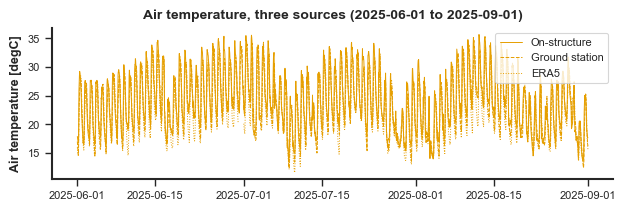

In [21]:
fig = figures.plot_three_source_series(
    df, 'tair', sources=SOURCES, span=COMPARISON_SPAN,
    title='Air temperature, three sources',
    save_path=OUTPUT_DIR, filename='PF_F08_tair_series')

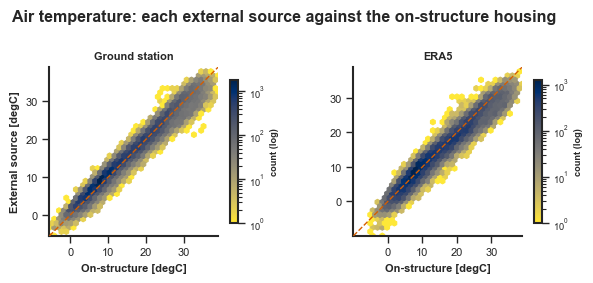

In [22]:
fig = figures.plot_source_scatter(
    df, 'tair', reference='str',
    title='Air temperature: each external source against the on-structure housing',
    save_path=OUTPUT_DIR, filename='PF_F09_tair_scatter')

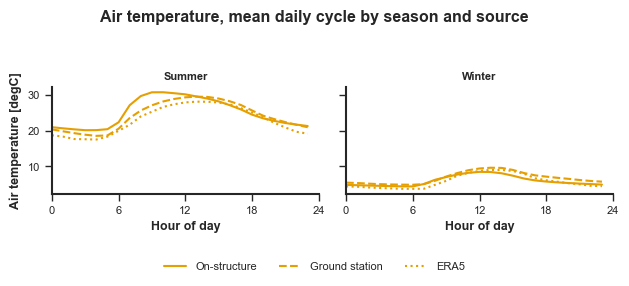

In [23]:
fig = figures.plot_diurnal_comparison(
    df, 'tair', DIURNAL_SEASONS, SEASON_MONTHS, sources=SOURCES,
    title='Air temperature, mean daily cycle by season and source',
    save_path=OUTPUT_DIR, filename='PF_F10_tair_diurnal')

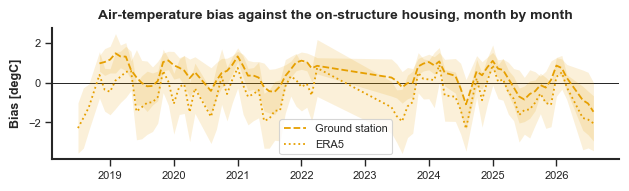

In [24]:
tair_stability = compare.agreement_stability(df, 'tair', reference='str',
                                             freq=STABILITY_FREQ,
                                             min_hours=STABILITY_MIN_HOURS)
fig = figures.plot_agreement_stability(
    tair_stability, 'tair',
    title='Air-temperature bias against the on-structure housing, month by month',
    save_path=OUTPUT_DIR, filename='PF_F11_tair_stability')

## Step 8 · Solar radiation, three sources compared

The same four views, then the calibration the temperature comparison has no equivalent of.

Radiation is the quantity where the reference is trustworthy over only a narrow window, so the
comparison is run twice: over the whole shared record, which says how the sources behave against
a channel that is partly condemned, and over the certified window alone, which is the only
stretch where the on-structure measurement can carry the weight of a calibration. The second is
the one the verdict rests on.

The calibration is restricted to daylight by default. Half of every day is a substituted zero in
the reference and a near-zero in both sources, and a statistic computed over the whole day is
dominated by hours in which all three agree that it is dark — which is agreement about the
position of the sun, not about radiation. The fitted slope and intercept are reported because
they are what a documented substitution would actually apply: they are the price of the
substitution, stated.

### Parameter Tuning Guidance

`DAYLIGHT_ONLY` and `NIGHT_ELEVATION` set the daylight restriction and the elevation defining
it; turning the restriction off inflates every correlation and shrinks every bias, and measures
the night rather than the radiation. Everything else matches step 7, deliberately, so that the
two quantities' tables can be read side by side.

In [25]:
sr_overall = compare.pairwise_agreement(df, 'sr', reference='str',
                                        min_hours=AMPLITUDE_MIN_HOURS)
sr_seasonal = compare.pairwise_agreement(df, 'sr', reference='str',
                                         season_months=SEASON_MONTHS, by='season',
                                         min_hours=AMPLITUDE_MIN_HOURS)
sr_agreement = pd.concat([sr_overall, sr_seasonal], ignore_index=True)
display(sr_agreement)
sr_agreement.to_csv(f'{OUTPUT_DIR}/PF_11_sr_agreement.csv', index=False)

tables.write_table(
    sr_agreement, f'{OUTPUT_DIR}/PF_T11_sr_agreement.tex',
    columns=[
        ('compared', tables.texttt),
        ('split', None),
        ('n', ','),
        ('bias', '.1f'),
        ('mae', '.1f'),
        ('rmse', '.1f'),
        ('r', '.3f'),
        ('amplitude_reference', '.1f'),
        ('amplitude_compared', '.1f'),
        ('amplitude_ratio', '.2f'),
        ('phase_lag_h', '.2f'),
    ])

,quantity,reference,compared,split,n,bias,mae,rmse,r,amplitude_reference,amplitude_compared,amplitude_ratio,peak_hour_reference,peak_hour_compared,phase_lag_h
0,sr,str,gs,all,5008,-87.693802,117.730637,203.971440,0.924870,1161.000000,598.750,0.515719,10.704981,11.264437,0.559457
1,sr,str,era5,all,5043,-56.472970,125.168292,206.557009,0.891576,1161.000000,609.730,0.525177,10.704981,11.596131,0.891150
2,sr,str,gs,winter,195,-42.015137,47.799085,108.923601,0.941982,673.016667,341.000,0.506674,10.990298,11.371034,0.380736
3,sr,str,gs,spring,2191,-82.158679,96.481167,176.430880,0.941124,1027.000000,693.500,0.675268,10.808790,11.203075,0.394285
4,sr,str,gs,summer,2598,-98.310330,140.274541,228.539177,0.916643,1189.666667,822.000,0.690950,10.607213,11.389663,0.782450
5,sr,str,gs,autumn,24,185.095625,185.446319,299.022931,0.917522,31.916667,500.000,15.665796,11.000000,11.084475,0.084475
6,sr,str,era5,winter,195,-20.514419,62.895615,124.068196,0.832218,673.016667,337.580,0.501592,10.990298,11.781939,0.791641
7,sr,str,era5,spring,2193,-49.172927,106.700587,185.618675,0.888201,1027.000000,713.260,0.694508,10.808790,11.612838,0.804048
8,sr,str,era5,summer,2631,-67.574962,144.474200,225.685393,0.893260,1189.666667,849.590,0.714141,10.607213,11.626862,1.019649
9,sr,str,era5,autumn,24,201.378125,202.210069,328.928561,0.948711,31.916667,490.345,15.363290,11.000000,11.345559,0.345559


'outputs/PF_T11_sr_agreement.tex'

In [26]:
sr_calibration = compare.calibrate_against_sensor(
    df, 'sr', certified_days, reference='str', season_months=SEASON_MONTHS,
    daylight_only=DAYLIGHT_ONLY, elevation=NIGHT_ELEVATION,
    min_hours=AMPLITUDE_MIN_HOURS)
display(sr_calibration)
sr_calibration.to_csv(f'{OUTPUT_DIR}/PF_12_sr_calibration.csv', index=False)

tables.write_table(
    sr_calibration, f'{OUTPUT_DIR}/PF_T12_sr_calibration.tex',
    columns=[
        ('compared', tables.texttt),
        ('split', None),
        ('n', ','),
        ('bias', '.1f'),
        ('rmse', '.1f'),
        ('r', '.3f'),
        ('slope', '.3f'),
        ('intercept', '.1f'),
        ('r2', '.3f'),
        ('window_days', ','),
    ])

,quantity,reference,compared,split,n,bias,mae,rmse,r,amplitude_reference,amplitude_compared,amplitude_ratio,peak_hour_reference,peak_hour_compared,phase_lag_h,slope,intercept,r2,window_days,daylight_only
0,sr,str,gs,all,3194,-137.618725,184.237220,255.238612,0.888915,NaN,NaN,NaN,NaN,NaN,NaN,0.606883,53.360395,0.790170,224,True
1,sr,str,era5,all,3215,-88.486602,196.178124,258.696924,0.836020,NaN,NaN,NaN,NaN,NaN,NaN,0.578190,116.986177,0.698930,224,True
2,sr,str,gs,winter,96,-85.255122,97.003767,155.239168,0.916014,NaN,NaN,NaN,NaN,NaN,NaN,0.546631,20.370331,0.839081,224,True
3,sr,str,gs,spring,1302,-138.114583,162.216405,228.868969,0.910839,NaN,NaN,NaN,NaN,NaN,NaN,0.623111,26.432326,0.829627,224,True
4,sr,str,gs,summer,1783,-143.573210,203.863744,275.590620,0.878311,NaN,NaN,NaN,NaN,NaN,NaN,0.593660,75.350199,0.771431,224,True
5,sr,str,gs,autumn,13,342.038718,342.038718,406.290481,0.818987,NaN,NaN,NaN,NaN,NaN,NaN,21.848255,-36.431955,0.670740,224,True
6,sr,str,era5,winter,96,-41.581788,127.668594,176.823641,0.748681,NaN,NaN,NaN,NaN,NaN,NaN,0.449944,86.569656,0.560523,224,True
7,sr,str,era5,spring,1304,-82.619295,179.237806,240.712271,0.824865,NaN,NaN,NaN,NaN,NaN,NaN,0.565100,107.731419,0.680402,224,True
8,sr,str,era5,summer,1802,-98.552889,210.812177,272.699604,0.841246,NaN,NaN,NaN,NaN,NaN,NaN,0.581824,127.184903,0.707694,224,True
9,sr,str,era5,autumn,13,371.945641,372.834103,446.924042,0.908743,NaN,NaN,NaN,NaN,NaN,NaN,27.383373,-107.007288,0.825814,224,True


'outputs/PF_T12_sr_calibration.tex'

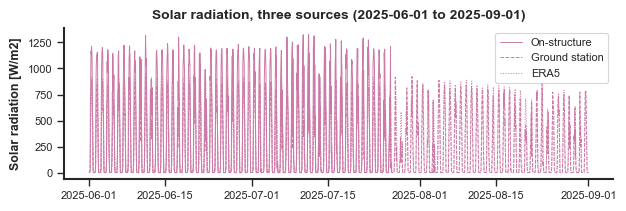

In [27]:
fig = figures.plot_three_source_series(
    df, 'sr', sources=SOURCES, span=COMPARISON_SPAN,
    title='Solar radiation, three sources',
    save_path=OUTPUT_DIR, filename='PF_F12_sr_series')

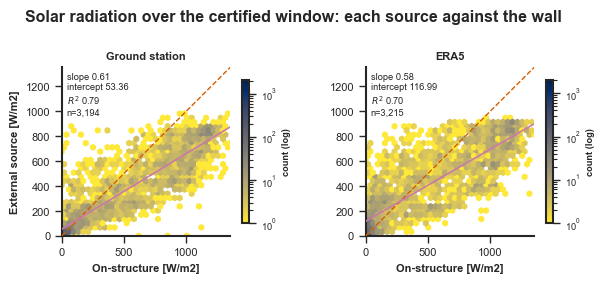

In [28]:
# The scatter is drawn over the certified window alone, with the fits from that window, because
# it is the panel a reader will quote and it must not show the condemned days.
certified_frame_hours = quality.restrict_to_days(df, certified_days)
fig = figures.plot_source_scatter(
    certified_frame_hours, 'sr', reference='str', fits=sr_calibration,
    title='Solar radiation over the certified window: each source against the wall',
    save_path=OUTPUT_DIR, filename='PF_F13_sr_scatter')

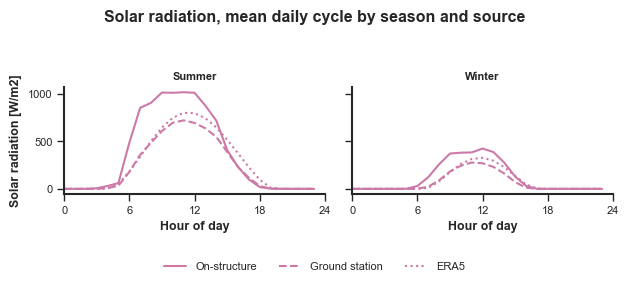

In [29]:
fig = figures.plot_diurnal_comparison(
    df, 'sr', DIURNAL_SEASONS, SEASON_MONTHS, sources=SOURCES,
    title='Solar radiation, mean daily cycle by season and source',
    save_path=OUTPUT_DIR, filename='PF_F14_sr_diurnal')

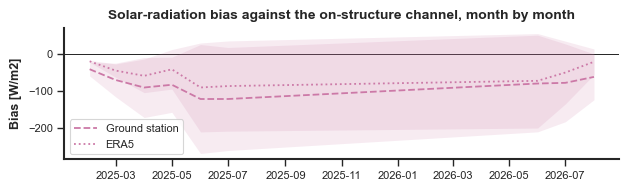

In [30]:
sr_stability = compare.agreement_stability(df, 'sr', reference='str',
                                           freq=STABILITY_FREQ,
                                           min_hours=STABILITY_MIN_HOURS)
fig = figures.plot_agreement_stability(
    sr_stability, 'sr',
    title='Solar-radiation bias against the on-structure channel, month by month',
    save_path=OUTPUT_DIR, filename='PF_F15_sr_stability')

## Step 9 · Compatibility and substitution

The verdict, stated separately for each quantity and each source: whether it is a defensible
substitute for the on-structure measurement, what transformation that would require, the period
over which the evidence applies, and the limitation carried into the later inclination analysis.
A source may be useful without being interchangeable. A stable bias or amplitude difference may
permit a documented transformation, whereas an unstable seasonal relation, an inconsistent
phase, or poor correspondence during the valid local window rules substitution out.

The rows below are written from the numbers above them, and `quality.verdict_table` refuses a row
that omits its evidence window: a verdict missing the period it rests on is not a weaker
verdict, it is an unsupported one.

Whether this study also exports an aligned hourly forcing dataset for later studies is decided
here rather than in advance. The point of the study is to establish which source is fit to be
exported, and building the export first would prejudge it.

### Parameter Tuning Guidance

Nothing in this step is tunable. Every cell below reads a number computed earlier; the prose in
each verdict is the author's and is the one thing in this notebook that no parameter controls.

In [31]:
# The evidence each verdict rests on, pulled from the tables above so that the numbers quoted in
# the verdict and the numbers in the report cannot drift apart.
evidence = {
    'tair': tair_agreement.query("split == 'all'").set_index('compared'),
    'sr': sr_calibration.query("split == 'all'").set_index('compared'),
}
for quantity, frame in evidence.items():
    print(f'\n{quantity}')
    display(frame[['n', 'bias', 'rmse', 'r']])

full_window = f'{df.index.min():%Y-%m-%d} to {df.index.max():%Y-%m-%d}'
certified_window = (f'{certified["first"]:%Y-%m-%d} to '
                    f'{certified["last"]:%Y-%m-%d}, '
                    f'{certified["n_days"]} days')
print(f'\nfull shared record   {full_window}')
print(f'certified radiation  {certified_window}')


tair


,n,bias,rmse,r
compared,,,,
gs,47044,0.369151,1.636944,0.983047
era5,49181,-0.564442,2.198214,0.969616



sr


,n,bias,rmse,r
compared,,,,
gs,3194,-137.618725,255.238612,0.888915
era5,3215,-88.486602,258.696924,0.836020



full shared record   2018-01-01 to 2026-08-20
certified radiation  2025-02-20 to 2026-08-19, 224 days


In [32]:
# TODO: write one row per quantity per source once the numbers above have been read. Each row
# states the verdict, the transformation it would require, the window its evidence covers, and
# the limitation it carries. `quality.verdict_table` refuses a row that omits any of them.
#
# verdict = quality.verdict_table([
#     {'quantity': 'tair', 'source': 'era5', 'verdict': ...,
#      'transformation': ..., 'evidence_window': full_window, 'limitation': ...},
#     ...
# ])
# display(verdict)
# verdict.to_csv(f'{OUTPUT_DIR}/PF_13_verdict.csv', index=False)
# tables.write_table(
#     verdict, f'{OUTPUT_DIR}/PF_T13_verdict.tex',
#     columns=[('quantity', tables.texttt), ('source', tables.texttt),
#              ('verdict', None), ('transformation', None),
#              ('evidence_window', None), ('limitation', None)])